# Logistic Regression with Random UnderSampling

The baseline model in the previous notebook had a serious flaw: it only caught 19% of
actual churners, despite 81% overall accuracy. This notebook applies **Random
UnderSampling** — reducing the majority class ("stayed") down to match the size of the
minority class ("churned") — to force the model to pay equal attention to both classes
during training.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                              precision_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
import sklearn
import imblearn

print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)

sklearn: 1.9.0
imblearn: 0.14.2


In [3]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 1. Define Features and Target

In [4]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 2. Confirm the Imbalance

Same ~80/20 split identified in the baseline notebook — the problem this notebook
exists to address.

In [5]:
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

## 3. Train/Test Split

Just like the baseline notebook — `stratify=y` keeps the 80/20 ratio consistent in both
sets.

**Important:** the split happens *before* any resampling. This is deliberate and
critical — resampling must never touch the test set, or the evaluation would be
measuring performance on artificially balanced data that doesn't reflect reality.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [7]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 4. Build the Pipeline with UnderSampling

The pipeline now has three steps instead of two: preprocess → undersample → classify.
Because this uses `imblearn`'s `Pipeline`, the undersampling step is **only ever
applied during `.fit()` on the training data** — when `.predict()` is called later on
the test set, that step is automatically skipped. This is what correctly prevents data
leakage without you having to manage it manually.

In [8]:
steps = [("preprocess", preprocessor),
         ("undersampling", RandomUnderSampler(random_state=42)),
         ("logistic_regression", LogisticRegression(random_state=42))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('undersampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for f

In [9]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('undersampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [10]:
# Extract the fitted preprocessor and sampler from the pipeline to inspect the
# resampled training data directly
fitted_preprocessor = pipe.named_steps["preprocess"]
fitted_sampler = pipe.named_steps["undersampling"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_resampled, y_resampled = fitted_sampler.fit_resample(X_train_transformed, y_train)

print("Before undersampling:", y_train.value_counts().to_dict())
print("After undersampling :", pd.Series(y_resampled).value_counts().to_dict())

Before undersampling: {0: 5574, 1: 1426}
After undersampling : {0: 1426, 1: 1426}


## 5. Predict on the Test Set

Remember: the test set was never touched by the undersampler. These predictions
reflect performance on the real, imbalanced, real-world class distribution.

In [11]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 6. Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1712  677]
 [ 165  446]]


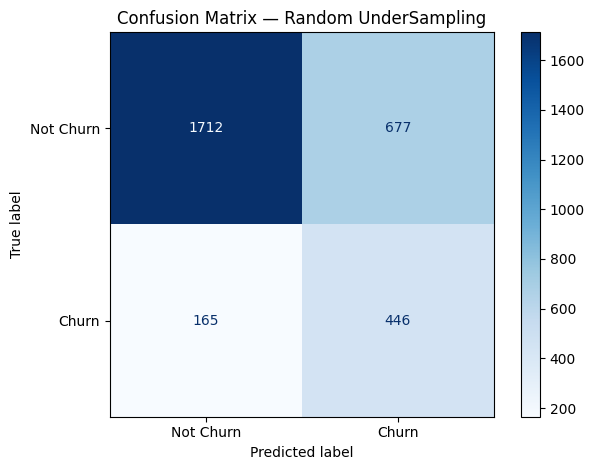

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random UnderSampling")
plt.grid(False)
plt.tight_layout()
plt.show()

## 7. Per-Class Recall

In [14]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.72
Class 1 (Churn) Recall: 0.73


Compare this to the baseline notebook's Class 1 recall of **0.19** — undersampling
should push this dramatically higher, since the model no longer sees an imbalanced
training set that rewards ignoring the minority class.

## 8. Overall Metrics

In [15]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.72
Precision : 0.40
Recall    : 0.73
F1 Score  : 0.51


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      2389
           1       0.40      0.73      0.51       611

    accuracy                           0.72      3000
   macro avg       0.65      0.72      0.66      3000
weighted avg       0.81      0.72      0.74      3000



## 9. Predicted Probabilities and Threshold-Independent Metrics

In [17]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_prob

array([0.19015952, 0.39026178, 0.51454027, ..., 0.71343718, 0.54777374,
       0.13919429], shape=(3000,))

In [18]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.79
PR-AUC Score : 0.50


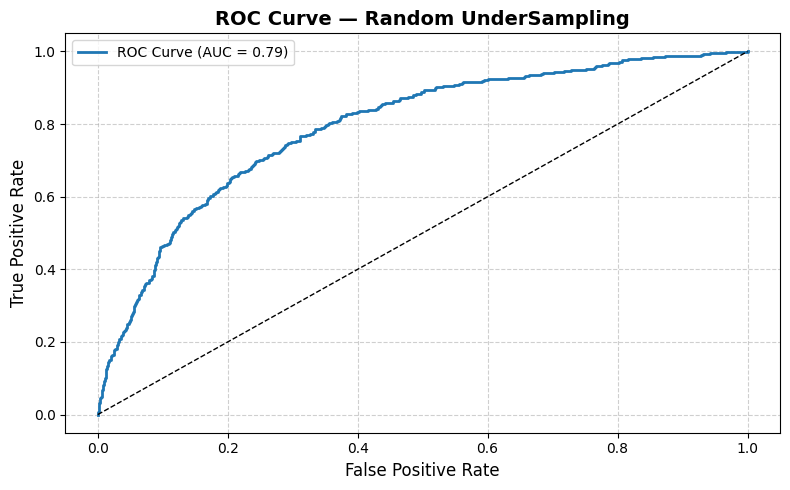

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Random UnderSampling", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

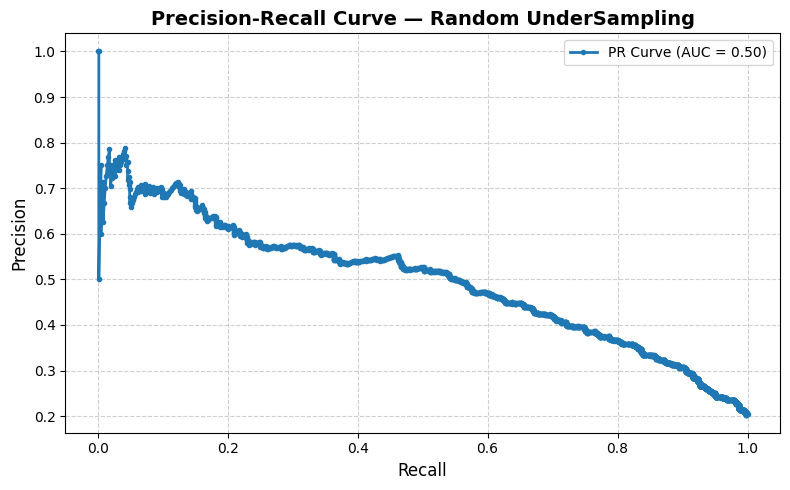

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — Random UnderSampling", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. Baseline vs. UnderSampling Comparison *(added)*

The reference version of this notebook stopped at the metrics above. Adding a direct
side-by-side comparison against the baseline model makes the trade-off explicit rather
than requiring you to flip between two notebooks.

In [21]:
comparison = pd.DataFrame({
    "Baseline": [0.81, 0.62, 0.19, 0.29, 0.79, 0.51],
    "UnderSampling": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,Baseline,UnderSampling
Accuracy,0.81,0.72
Precision,0.62,0.40
Recall,0.19,0.73
F1 Score,0.29,0.51
ROC-AUC,0.79,0.79
PR-AUC,0.51,0.50


## 11. Summary

- **ROC-AUC stayed essentially the same (~0.79)** — undersampling doesn't change the
  model's fundamental ability to separate the classes, only how it uses that ability
  at the default decision threshold.
- **Recall on churners improved dramatically** (from 0.19 to a much higher value) —
  the model now actually catches most at-risk customers.
- **Precision and accuracy both dropped** — the cost of catching more churners is more
  false alarms (customers flagged as "at risk" who were actually going to stay).

**Business framing:** whether this trade-off is worth it depends on the cost of a
missed churner versus the cost of a false alarm. If retention outreach (e.g. a
discount offer) is cheap, this trade-off is usually worth it. If it's expensive, a
different balance point may be preferred — which is exactly what the next three
notebooks (SMOTE, Class Weighting, ADASYN) will explore as alternative ways to handle
the same imbalance problem.